# dudas pal grupete:

Será importante guardar info sobre si algo es persona o no? (a partir de los qid). La pregunta viene de que de esta manera puede ser más fácil (se me olvido que estaba diciendo)

In [1]:
import os
import pathlib

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

In [13]:
data_dir = '../Datasets'
files = os.listdir(data_dir)
print(files)

# Material de trabajo:
dfs_dict = {file_name: pd.read_csv(data_dir + "/" + file_name) for file_name in files if file_name.endswith('.csv')}
big_df = pd.concat(dfs_dict.values(), ignore_index=True)

['data_NER', 'chile.csv', 'mexico.csv', 'costa_rica.csv', 'README.md', 'usa.csv', 'argentina.csv', 'bolivia.csv', 'guatemala.csv', 'el_salvador.csv', 'honduras.csv']


### 1) Tripletas por archivo

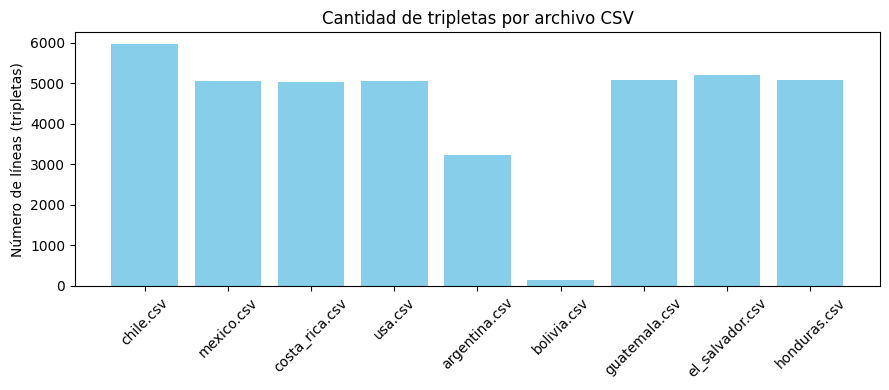

In [35]:
line_counts = {}
for file_name, df in dfs_dict.items():
    line_counts[file_name] = len(df)

plt.figure(figsize=(9, 4))
plt.bar(line_counts.keys(), line_counts.values(), color="skyblue")
plt.ylabel("Número de líneas (tripletas)")
plt.title("Cantidad de tripletas por archivo CSV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

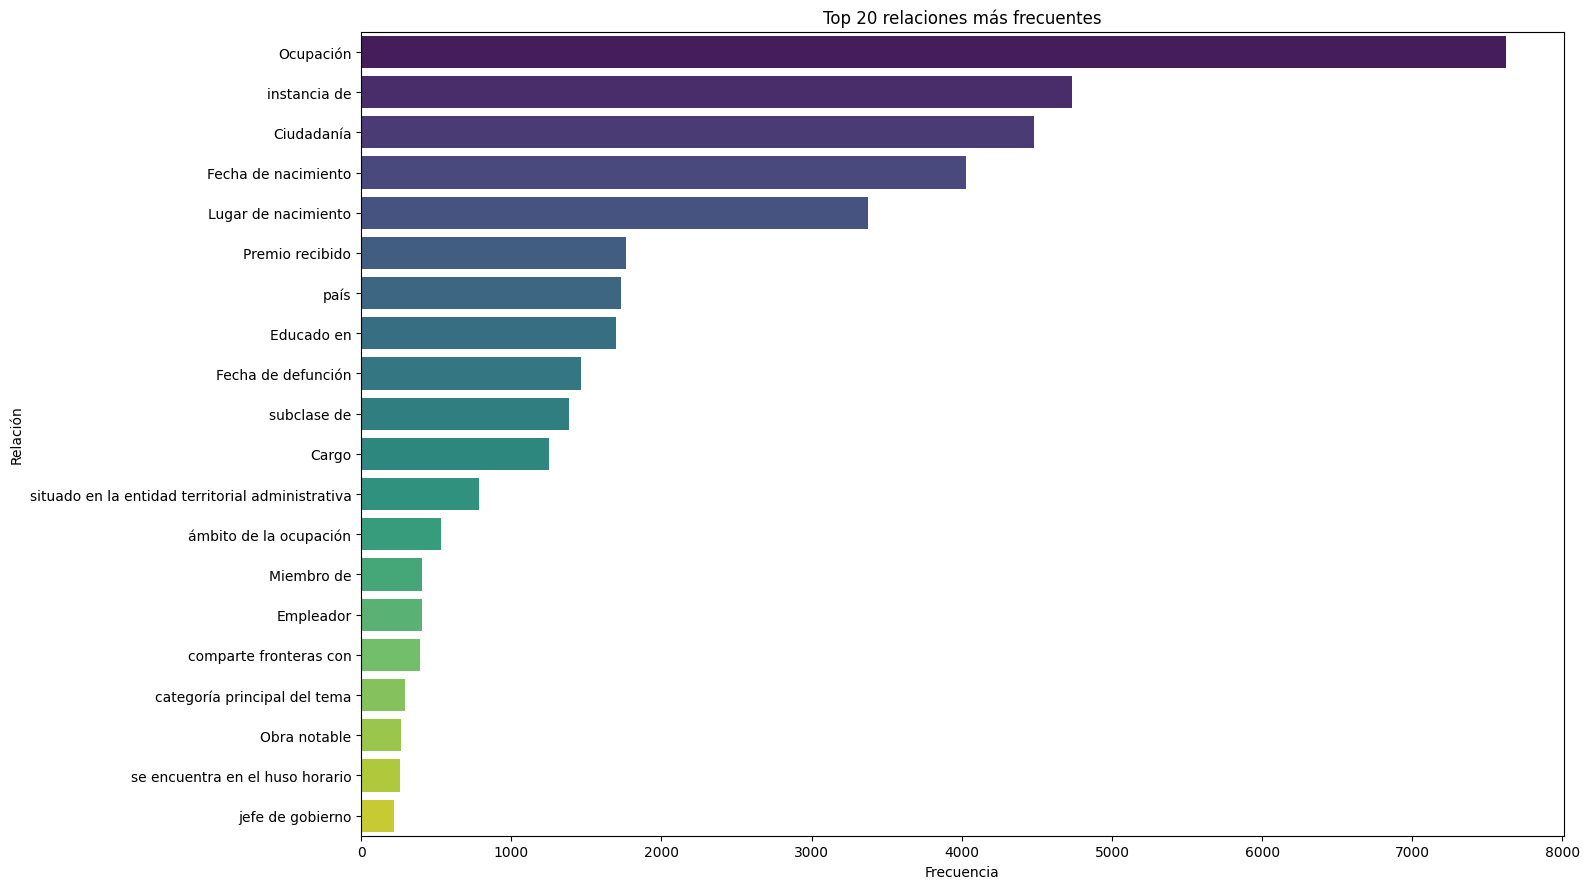

In [40]:
relation_counts = big_df['relacion'].value_counts().reset_index()

top_n = 20
plt.figure(figsize=(16, 9))
sns.barplot(
    data=relation_counts.head(top_n),
    y='relacion',
    x='count',
    hue='relacion',
    palette='viridis',
    legend=False
)
plt.xlabel('Frecuencia')
plt.ylabel('Relación')
plt.title(f'Top {top_n} relaciones más frecuentes')
plt.tight_layout()
plt.show()


### 2) Relaciones promedio por entidad

In [4]:
import math

def relations_per_entity_hist_all(folder_path):
    csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]
    total_files = len(csv_files)

    max_x = 0
    max_y = 0
    data_dict = {}

    for file in csv_files:
        df = pd.read_csv(os.path.join(folder_path, file))
        entity_degrees = df['entidad'].value_counts()
        data_dict[file] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, file in enumerate(csv_files):
        sns.histplot(data_dict[file], bins=30, kde=False, ax=axes[i])
        axes[i].set_xlim(0, max_x * 1.05)       # margen de 5% extra
        axes[i].set_ylim(1, max_y * 1.2)        # margen superior
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(file.replace('.csv', ''))

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


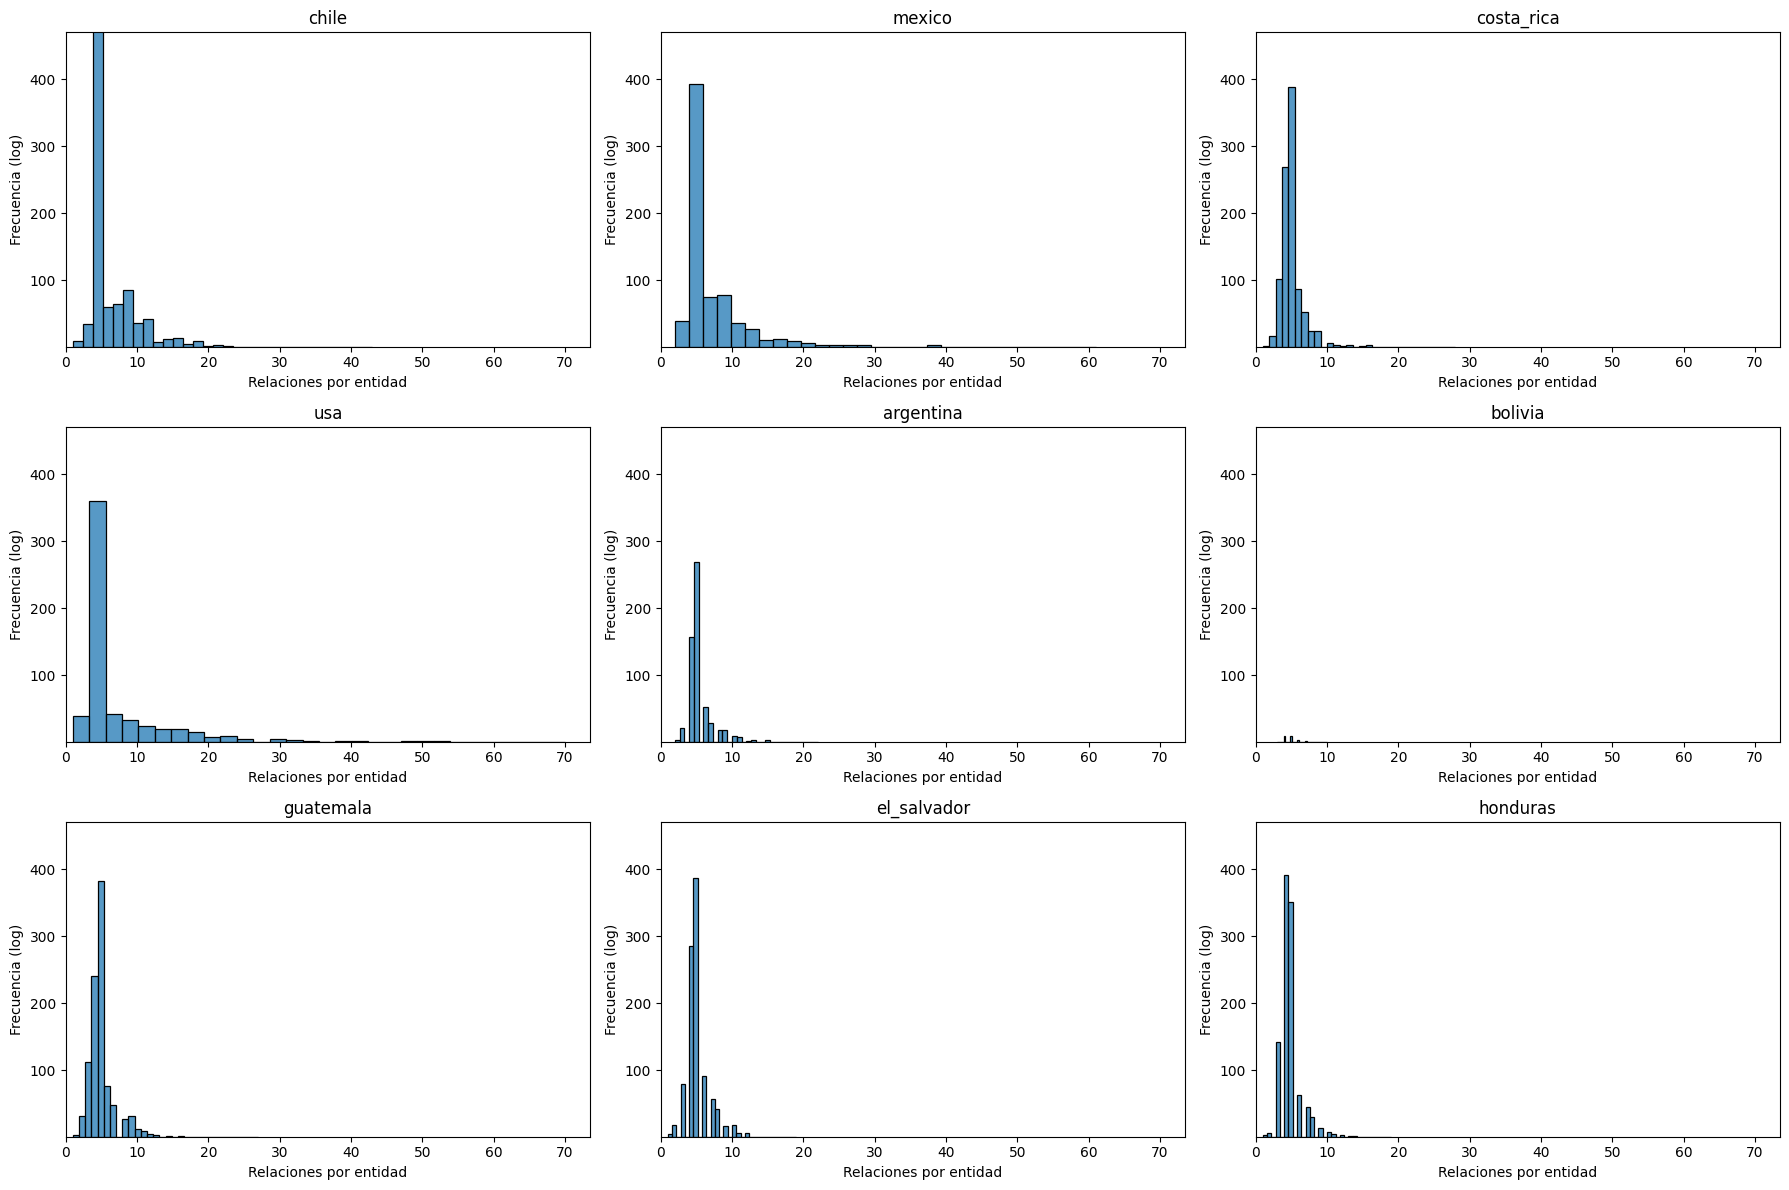

In [5]:
relations_per_entity_hist_all(data_dir)

In [7]:
tsv = pd.read_csv("../Datasets/data_NER/bolivia.tsv", sep="\t")
tsv

,Apiaguaiki Tumpa,instancia_de: ser humano,subclase_de: -
0,Apolinar Aquino,instancia_de: ser humano,subclase_de: -
1,Apolinar Camacho,instancia_de: ser humano,subclase_de: -
2,Apolinar Jaén,instancia_de: ser humano,subclase_de: -
3,Ariel Juárez,instancia_de: ser humano,subclase_de: -
4,Ariel Villazón Torrico,instancia_de: ser humano,subclase_de: -
5,Armando Chirveches,instancia_de: ser humano,subclase_de: -
6,Arminda Alba,instancia_de: ser humano,subclase_de: -
7,Arturo Galarza,instancia_de: ser humano,subclase_de: -
8,Arturo Reque Meruvia,instancia_de: ser humano,subclase_de: -
9,Helmut Gutiérrez,instancia_de: ser humano,subclase_de: -
